In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ast

In [32]:
# Data Sources
data_albums = pd.read_csv("../data/spotify_albums.csv")
data_artists = pd.read_csv("../data/spotify_artists.csv")
data_tracks = pd.read_csv("../data/spotify_tracks.csv")

# Features Extracted
data_audio = pd.read_csv("../data/low_level_audio_features.csv")
data_lyrics = pd.read_csv("../data/lyrics_features.csv")

In [33]:
# show the number of observations and features,
# names of the features,
# and the first 5 rows for each dataset

for name, df in {
    "albums": data_albums,
    "artists": data_artists,
    "tracks": data_tracks,
    "audio": data_audio,
    "lyrics": data_lyrics,
}.items():
    print(f"\n{name.upper()}")
    print(f"Observations: {len(df)}, Features: {len(df.columns)}")
    print(df.columns.tolist())
    display(df.head(5))


ALBUMS
Observations: 75511, Features: 16
['Unnamed: 0', 'album_type', 'artist_id', 'available_markets', 'external_urls', 'href', 'id', 'images', 'name', 'release_date', 'release_date_precision', 'total_tracks', 'track_id', 'track_name_prev', 'uri', 'type']


,Unnamed: 0,album_type,artist_id,available_markets,external_urls,href,id,images,name,release_date,release_date_precision,total_tracks,track_id,track_name_prev,uri,type
0,0,single,3DiDSECUqqY1AuBP8qtaIa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1g...,https://api.spotify.com/v1/albums/1gAM7M4rBwEb...,1gAM7M4rBwEbSPeAQR2nx1,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",If I Ain't Got You EP,2019-02-08,day,6,2iejTMy9XZ8Gaae0aQ2yl0,track_32,spotify:album:1gAM7M4rBwEbSPeAQR2nx1,album
1,1,album,6s1pCNXcbdtQJlsnM1hRIA,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/4K...,https://api.spotify.com/v1/albums/4KfJZV7WfolY...,4KfJZV7WfolYlxBzOTo66s,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Shostakovich Symphony No.5 - Four Romances on ...,2019-03-01,day,8,1WQfghEjszJJ4H8MAWrQ2C,track_11,spotify:album:4KfJZV7WfolYlxBzOTo66s,album
2,2,single,5YjfNaHq05WrwldRe1QSBc,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/7n...,https://api.spotify.com/v1/albums/7nLYY7uAVUb5...,7nLYY7uAVUb57kpd7tZxnS,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Take My Bass,2019-03-14,day,1,3jJKj4QTK3v18ZSwpk7AcV,track_15,spotify:album:7nLYY7uAVUb57kpd7tZxnS,album
3,3,single,2G9Vc16JCpnZmK4uGH46Fa,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/6p...,https://api.spotify.com/v1/albums/6p20Rt4x2Qn5...,6p20Rt4x2Qn5mUMRi1s6pj,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Hypnotizing (Are U),2016-11-16,day,1,1xGtDafUZbHyYC3Xarcbrj,track_46,spotify:album:6p20Rt4x2Qn5mUMRi1s6pj,album
4,4,single,2dwM9OcE4c3Ph1UBINSodx,"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",{'spotify': 'https://open.spotify.com/album/1X...,https://api.spotify.com/v1/albums/1XeoOqC1q7U2...,1XeoOqC1q7U2iyLEQJ64cu,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",Sunshine,2018-07-20,day,1,0gWtsXvXOzAT6FtM3ur8in,track_10,spotify:album:1XeoOqC1q7U2iyLEQJ64cu,album



ARTISTS
Observations: 56129, Features: 9
['Unnamed: 0', 'artist_popularity', 'followers', 'genres', 'id', 'name', 'track_id', 'track_name_prev', 'type']


,Unnamed: 0,artist_popularity,followers,genres,id,name,track_id,track_name_prev,type
0,0,44,23230,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",4mGnpjhqgx4RUdsIJiURdo,Juliano Cezar,0wmDmAILuW9e2aRttkl4aC,track_9,artist
1,1,22,313,[],1dLnVku4VQUOLswwDFvRc9,The Grenadines,4wqwj0gA8qPZKLl5WVqXml,track_30,artist
2,2,26,1596,['danish pop rock'],6YVY310fjfUzKi8hiqR7iK,Gangway,1bFqWDbvHmZe2f4Nf9qaD8,track_38,artist
3,3,31,149,['uk alternative pop'],2VElyouiCfoYPDJluzwJwK,FADES,3MFSUBAidPzRBbIS7BDj1S,track_34,artist
4,4,21,11,['french baroque'],4agVy03qW8juSysCTUOuDI,Jean-Pierre Guignon,2r3q57FhxdsCyYr0kuDq4b,track_26,artist



TRACKS
Observations: 101939, Features: 32
['Unnamed: 0', 'acousticness', 'album_id', 'analysis_url', 'artists_id', 'available_markets', 'country', 'danceability', 'disc_number', 'duration_ms', 'energy', 'href', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'lyrics', 'mode', 'name', 'playlist', 'popularity', 'preview_url', 'speechiness', 'tempo', 'time_signature', 'track_href', 'track_name_prev', 'track_number', 'uri', 'valence', 'type']


,Unnamed: 0,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track



AUDIO
Observations: 101909, Features: 209
['Unnamed: 0', 'Chroma_1', 'Chroma_10', 'Chroma_11', 'Chroma_12', 'Chroma_2', 'Chroma_3', 'Chroma_4', 'Chroma_5', 'Chroma_6', 'Chroma_7', 'Chroma_8', 'Chroma_9', 'MEL_1', 'MEL_10', 'MEL_100', 'MEL_101', 'MEL_102', 'MEL_103', 'MEL_104', 'MEL_105', 'MEL_106', 'MEL_107', 'MEL_108', 'MEL_109', 'MEL_11', 'MEL_110', 'MEL_111', 'MEL_112', 'MEL_113', 'MEL_114', 'MEL_115', 'MEL_116', 'MEL_117', 'MEL_118', 'MEL_119', 'MEL_12', 'MEL_120', 'MEL_121', 'MEL_122', 'MEL_123', 'MEL_124', 'MEL_125', 'MEL_126', 'MEL_127', 'MEL_128', 'MEL_13', 'MEL_14', 'MEL_15', 'MEL_16', 'MEL_17', 'MEL_18', 'MEL_19', 'MEL_2', 'MEL_20', 'MEL_21', 'MEL_22', 'MEL_23', 'MEL_24', 'MEL_25', 'MEL_26', 'MEL_27', 'MEL_28', 'MEL_29', 'MEL_3', 'MEL_30', 'MEL_31', 'MEL_32', 'MEL_33', 'MEL_34', 'MEL_35', 'MEL_36', 'MEL_37', 'MEL_38', 'MEL_39', 'MEL_4', 'MEL_40', 'MEL_41', 'MEL_42', 'MEL_43', 'MEL_44', 'MEL_45', 'MEL_46', 'MEL_47', 'MEL_48', 'MEL_49', 'MEL_5', 'MEL_50', 'MEL_51', 'MEL_52', '

,Unnamed: 0,Chroma_1,Chroma_10,Chroma_11,Chroma_12,Chroma_2,Chroma_3,Chroma_4,Chroma_5,Chroma_6,...,Tonnetz_4,Tonnetz_5,Tonnetz_6,ZCR,entropy_energy,spectral_bandwith,spectral_centroid,spectral_rollOff_max,spectral_rollOff_min,track_id
0,0,0.438296,0.472769,0.427441,0.436688,0.467697,0.493862,0.512244,0.568658,0.560524,...,0.018434,-0.001759,-0.006392,0.067966,-89.113389,2564.247669,3558.400706,4508.506071,367.831109,19YEk4OVQZn3GfoxbpNrU6
1,1,0.596605,0.368288,0.285263,0.302211,0.905805,0.510909,0.221708,0.311248,0.491277,...,0.046941,0.005665,-0.026928,0.047308,-127.945239,2370.181495,1499.689590,3647.394611,230.165275,6zJms3MX11Qu1IKF44LoRW
2,2,0.505224,0.500420,0.506773,0.488258,0.498356,0.573582,0.690761,0.742858,0.686282,...,-0.006929,0.004968,0.008947,0.058463,-238.285176,2973.294736,1543.550034,5623.349330,187.290534,1WugzepXsLjnsM0K4UaWYc
3,3,0.525690,0.666469,0.579492,0.498920,0.598528,0.631578,0.501693,0.500468,0.587101,...,-0.027382,-0.009689,0.001402,0.080547,-148.785733,2716.749483,3017.248824,5799.931595,160.940693,1pSlTbCrUJ9rmwj5CNNrX4
4,4,0.632214,0.503698,0.496942,0.611532,0.634613,0.697265,0.557012,0.530836,0.444279,...,0.003728,-0.002780,-0.010120,0.084945,-176.618314,3096.692876,2118.686992,6560.018666,229.131948,5yruvWJs3mL00w4slpCVzN



LYRICS
Observations: 94954, Features: 8
['Unnamed: 0', 'mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words', 'sentence_similarity', 'track_id', 'vocabulary_wealth']


,Unnamed: 0,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,track_id,vocabulary_wealth
0,0,-1.00,-1.00,-1,-1,-1.000000,5KIfHjHI5NIsPHNt58qua0,-1.00
1,1,1.10,5.65,31,326,0.043011,13keyz9ikBe6ZpRasw7l4X,0.45
2,2,1.37,4.77,74,532,0.050352,1WugzepXsLjnsM0K4UaWYc,0.59
3,3,1.95,3.38,72,430,0.028560,2MO6oEAlMKcsfI8xP3yoy8,0.49
4,4,1.16,2.99,68,368,0.047849,1i4St7fmSUE9nB3R9n8fol,0.47


> Each dataframe is shown for their first 5 rows. They are also manually inspected through their respective csv files.

##### Research Questions (Step 1)

**Research Questions**
1. Is artist popularity significantly associated with track popularity?
2. How well can audio features predict track popularity?

#### Pre-processing

> Albums, Lyrics, and Audio dataframes are removed completely since they are not related to the research questions.

In [34]:
# remove album, lyrics, and audio dataframes
del data_albums
del data_lyrics
del data_audio

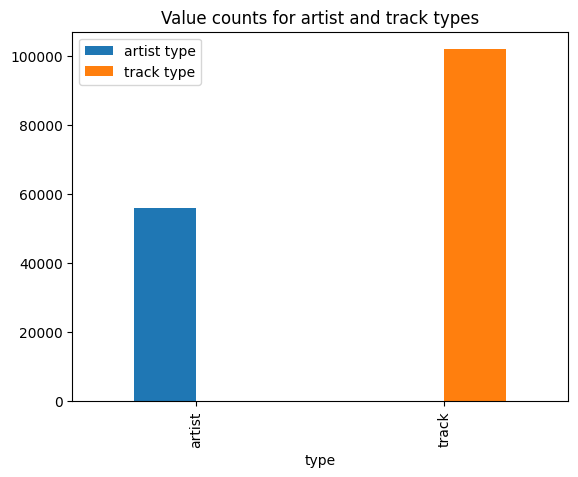

In [35]:
# show the count of variables in the type column
counts = pd.DataFrame({
    "artist type": data_artists["type"].value_counts(),
    "track type": data_tracks["type"].value_counts()
})

counts.plot.bar()
plt.title("Value counts for artist and track types")
plt.show()

> As it can be seen from the above count plot, the "type" column for both data_artists and data_tracks is repetitive.

In [36]:
empty_genres = data_artists["genres"].apply(lambda x: len(ast.literal_eval(x)) == 0)

print("Number of empty genre lists:", empty_genres.sum())
print("Percentage:", empty_genres.mean() * 100)

Number of empty genre lists: 23540
Percentage: 41.93910456270377


> In the artists dataframe, the first column that is called "unnamed" and the column "track_name_prev" can be removed since they are not needed. The column "type" is not needed since its only value is "artist". The "followers" column will not be needed, since we already have the "popularity" column that has numerical values from 1 to 100 calculated by the original authors of the paper to create a numerical measure of the artists' popularity. Finally, the column "genres" is decided to be not needed since it is overly detailed and has missing values.
> We only need the artist id, their popularity, and the corresponding track ids, so that we can relate the artist poularity to the tracks.

> In the tracks dataframe, the first column that is called "unnamed", and the columns "album_id", "analysis_url", "available_markets", "country", "disc_number", "href", "lyrics", "playlist", "preview_url", "speechiness", "time_signature", "track_href", "track_name_prev", "track_number", "uri", "track_name_prev", "type" can be removed since they are not needed.

Key: As previously mentioned, this is the estimated overall key of the track
. It uses standard Pitch Class notation (e.g., 0 = C, 1 = C♯/D♭, 2 = D). If no key is detected, the value is -1
Speechiness: This feature detects the presence of spoken words in a track
. The more the recording resembles speech (such as a talk show, audio book, or poetry), the closer the value will be to 1.0
Time_signature: This is an estimated overall meter of a track
. It is a notational convention that specifies how many beats are in each bar (or measure)

In [37]:
# remove unnecesary features before merging
data_artists = data_artists.drop(columns=["Unnamed: 0", "followers", "genres", "track_name_prev", "type"], errors="ignore")

data_tracks = data_tracks.drop(columns=["Unnamed: 0", "album_id", "analysis_url", "available_markets", "country",
                                         "disc_number", "href", "lyrics", "playlist", "preview_url", "track_href", 
                                         "track_name_prev", "track_number", "uri", "track_name_prev", "type"], errors="ignore")

In [38]:
# display the first 5 rows of the tracks and artists dataframes
for name, df in {
    "artists": data_artists,
    "tracks": data_tracks,
}.items():
    print(f"\n{name.upper()}")
    display(df.head(5))


ARTISTS


,artist_popularity,id,name,track_id
0,44,4mGnpjhqgx4RUdsIJiURdo,Juliano Cezar,0wmDmAILuW9e2aRttkl4aC
1,22,1dLnVku4VQUOLswwDFvRc9,The Grenadines,4wqwj0gA8qPZKLl5WVqXml
2,26,6YVY310fjfUzKi8hiqR7iK,Gangway,1bFqWDbvHmZe2f4Nf9qaD8
3,31,2VElyouiCfoYPDJluzwJwK,FADES,3MFSUBAidPzRBbIS7BDj1S
4,21,4agVy03qW8juSysCTUOuDI,Jean-Pierre Guignon,2r3q57FhxdsCyYr0kuDq4b



TRACKS


,acousticness,artists_id,danceability,duration_ms,energy,id,instrumentalness,key,liveness,loudness,mode,name,popularity,speechiness,tempo,time_signature,valence
0,0.294,['3mxJuHRn2ZWD5OofvJtDZY'],0.698,235584.0,0.606,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.151,-7.447,0.0,Blood,28.0,0.0262,115.018,4.0,0.6220
1,0.863,['4xWMewm6CYMstu0sPgd9jJ'],0.719,656960.0,0.308,3VAX2MJdmdqARLSU5hPMpm,0.000000,6.0,0.253,-10.340,1.0,The Ugly Duckling,31.0,0.9220,115.075,3.0,0.5890
2,0.750,['3hYaK5FF3YAglCj5HZgBnP'],0.466,492840.0,0.931,1L3YAhsEMrGVvCgDXj2TYn,0.000000,4.0,0.938,-13.605,0.0,Jimmy Launches His Own Range Of Greetings Cards,31.0,0.9440,79.565,4.0,0.0850
3,0.763,['2KQsUB9DRBcJk17JWX1eXD'],0.719,316578.0,0.126,6aCe9zzoZmCojX7bbgKKtf,0.000000,3.0,0.113,-20.254,0.0,The Crime At Pickets Mill,14.0,0.9380,112.822,3.0,0.5330
4,0.770,['3hYaK5FF3YAglCj5HZgBnP'],0.460,558880.0,0.942,1Vo802A38tPFHmje1h91um,0.000000,7.0,0.917,-13.749,1.0,Setup + Punchline = Joke,32.0,0.9430,81.260,4.0,0.0906


> Before merging, the names of the columns "id" and "name" in the artists dataframe will be changed to be "artist_id" and "artist_name". 

> Also, in the tracks dataframe, the names of the columns "id", "popularity", and "name" will be changed to be "track_id", "track_popularity", and "track_name".

In [39]:
data_artists = data_artists.rename(columns={
    "id": "artist_id",
    "name": "artist_name"
    })

data_tracks = data_tracks.rename(columns={
    "id": "track_id",
    "name": "track_name",
    "popularity": "track_popularity"
})

##### Missing Value Analysis

In [40]:
for name, df in {
    "artists": data_artists,
    "tracks": data_tracks,
}.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    
    print(f"\nMissing values in {name.upper()}:")
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)


Missing values in ARTISTS:
artist_name    1
dtype: int64

Missing values in TRACKS:
No missing values.


##### Unique Value Analysis

In [41]:
print("\nUniqueness checks")

print("\ndata_artists['artist_id']:")
print("Unique values:", data_artists["artist_id"].nunique())
print("Total rows:", len(data_artists))
print("All unique?", data_artists["artist_id"].is_unique)

print("\ndata_tracks['artists_id']:")
print("Unique values:", data_tracks["artists_id"].nunique())
print("Total rows:", len(data_tracks))
print("All unique?", data_tracks["artists_id"].is_unique)

print("\ndata_tracks['track_id']:")
print("Unique values:", data_tracks["track_id"].nunique())
print("Total rows:", len(data_tracks))
print("All unique?", data_tracks["track_id"].is_unique)


Uniqueness checks

data_artists['artist_id']:
Unique values: 56129
Total rows: 56129
All unique? True

data_tracks['artists_id']:
Unique values: 54673
Total rows: 101939
All unique? False

data_tracks['track_id']:
Unique values: 101939
Total rows: 101939
All unique? True


In [42]:
# show the duplicated artists_id rows in data_tracks
data_tracks[data_tracks["artists_id"].duplicated(keep=False)].sort_values("artists_id")

,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence
63856,0.000147,['0027wHZDQXpRll4ckwDGad'],0.480,221387.0,0.804,6Ovi0f2Ant45moF9zJNERx,0.000049,11.0,0.1240,-4.437,0.0,Second Soul,38.0,0.0508,140.015,4.0,0.315
56945,0.000636,['0027wHZDQXpRll4ckwDGad'],0.479,223320.0,0.887,0NVymX3RQRwxeKd80LNXhp,0.000086,2.0,0.2600,-5.115,1.0,Second Soul - Lenno & Jesse Oliver Remix Singl...,20.0,0.0346,127.981,4.0,0.201
89082,0.287000,['002oyMRzxTzEsBRLzACi8d'],0.549,217067.0,0.848,2nWAYmsTPSpza7X5tY6ZrH,0.000004,8.0,0.0933,-4.245,1.0,Piste.,44.0,0.0346,127.375,4.0,0.373
81771,0.034000,['002oyMRzxTzEsBRLzACi8d'],0.524,235107.0,0.841,4WqsrF7TJMNcXpALt6amw6,0.000016,2.0,0.0912,-4.444,0.0,Aamun Kuiskaus,51.0,0.0346,126.224,4.0,0.404
1169,0.371000,['002oyMRzxTzEsBRLzACi8d'],0.380,291253.0,0.425,0e0FFeJLCNrqO1abELMG21,0.015700,5.0,0.1750,-6.298,1.0,Häävalssi,35.0,0.0299,79.637,4.0,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95663,0.366000,['7zrkALJ9ayRjzysp4QYoEg'],0.629,201182.0,0.686,1GNvthYF2Ml5iflBVWjld7,0.878000,5.0,0.2320,-8.826,0.0,Turnmills - Edit,27.0,0.0350,115.020,4.0,0.535
58207,0.211000,['7zsin6IgVsR1rqSRCNYDwq'],0.545,192627.0,0.508,1GlvVIPOzbZyHIDaFF8eIc,0.000000,7.0,0.0944,-7.012,1.0,Let Her Go,50.0,0.0297,145.981,4.0,0.310
76618,0.213000,['7zsin6IgVsR1rqSRCNYDwq'],0.341,190280.0,0.539,6GRDI9suQHikFP6euIXnpq,0.000064,5.0,0.1090,-5.760,1.0,Hero,66.0,0.0265,174.564,4.0,0.267
87791,0.121000,['7zsin6IgVsR1rqSRCNYDwq'],0.642,210813.0,0.558,1dlsI0d27dT8R7XK9pTY8X,0.000005,8.0,0.0896,-9.661,1.0,Girl Who Washed Ashore,39.0,0.0288,78.017,4.0,0.803


> This shows that there are multiple tracks for some artists in the database, which is expected.

##### Tracks with Multiple Artists (ft.)

In [43]:
# show the duplicated artists_id rows in data_tracks
multi_artist_rows = data_tracks[
    data_tracks["artists_id"].apply(lambda x: len(ast.literal_eval(x)) > 1)
]

multi_artist_rows.head()

,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence
8,0.7520,"['5uNTrZ1JlKsnpTeFyKWPYO', '3pZ60MK5NPuXtBVJx1...",0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.1440,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.483
10,0.1010,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...",0.748,237667.0,0.666,01zME4q62SDPtD0hOSmTrG,0.000653,6.0,0.0976,-6.094,0.0,Creature Kind,47.0,0.0833,114.982,4.0,0.359
59,0.1480,"['7Czvx73uua4PB239Dza1Je', '2weGfox1CWg9HmmwDg...",0.790,174189.0,0.722,2kmakreNNd0A2UAPA1hIO3,0.000000,1.0,0.1720,-4.149,0.0,Soltera,49.0,0.0678,98.109,4.0,0.948
64,0.2880,"['1lNVs3gqrX6Qw01FqnP12N', '08HE59FnzdSLSYWues...",0.676,229956.0,0.719,6SO4EIIj2GPGPaX5KeWhoH,0.000000,1.0,0.1360,-4.847,1.0,Alma Gêmea,43.0,0.1240,107.064,4.0,0.769
76,0.0989,"['1NpKmfDYMhw1KJIIUCsX4O', '0Swkha61RB6f6xVAwy...",0.749,191592.0,0.479,3FaeRwOahQ8DyY1fSg6HO1,0.003200,0.0,0.3760,-4.789,1.0,Stay A Little Longer,46.0,0.1040,119.956,4.0,0.264


> Before merging, data_tracks rows with multiple artist_id should be handled. 

> It is decided that among the multiple artists, the one with the highest artist_popularity to be selected as to represent the strongest contributing artist influence.

In [44]:
# create a dictionary to look up the popularity of artists
artist_pop_lookup = data_artists.set_index("artist_id")["artist_popularity"].to_dict()

def get_popular_artist_id(artists_cell):
    artists_list = ast.literal_eval(artists_cell)
    
    # select artist with highest popularity
    best_artist = max(
        artists_list,
        key=lambda artist_id: artist_pop_lookup.get(artist_id, -1)
    )
    
    return best_artist  # return as string

# create new column
data_tracks["artist_id"] = data_tracks["artists_id"].apply(get_popular_artist_id)

In [45]:
multi_artist_rows = data_tracks[
    data_tracks["artists_id"].apply(lambda x: len(ast.literal_eval(x)) > 1)
]

multi_artist_rows.head()


,acousticness,artists_id,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence,artist_id
8,0.7520,"['5uNTrZ1JlKsnpTeFyKWPYO', '3pZ60MK5NPuXtBVJx1...",0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.1440,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.483,3pZ60MK5NPuXtBVJx1OkbN
10,0.1010,"['3FLUBwpAnaIlIKeaBfsxFe', '5r5Va4lVQ1zjEfbJSr...",0.748,237667.0,0.666,01zME4q62SDPtD0hOSmTrG,0.000653,6.0,0.0976,-6.094,0.0,Creature Kind,47.0,0.0833,114.982,4.0,0.359,5r5Va4lVQ1zjEfbJSrmCsS
59,0.1480,"['7Czvx73uua4PB239Dza1Je', '2weGfox1CWg9HmmwDg...",0.790,174189.0,0.722,2kmakreNNd0A2UAPA1hIO3,0.000000,1.0,0.1720,-4.149,0.0,Soltera,49.0,0.0678,98.109,4.0,0.948,7Czvx73uua4PB239Dza1Je
64,0.2880,"['1lNVs3gqrX6Qw01FqnP12N', '08HE59FnzdSLSYWues...",0.676,229956.0,0.719,6SO4EIIj2GPGPaX5KeWhoH,0.000000,1.0,0.1360,-4.847,1.0,Alma Gêmea,43.0,0.1240,107.064,4.0,0.769,08HE59FnzdSLSYWuesN8hm
76,0.0989,"['1NpKmfDYMhw1KJIIUCsX4O', '0Swkha61RB6f6xVAwy...",0.749,191592.0,0.479,3FaeRwOahQ8DyY1fSg6HO1,0.003200,0.0,0.3760,-4.789,1.0,Stay A Little Longer,46.0,0.1040,119.956,4.0,0.264,1NpKmfDYMhw1KJIIUCsX4O


In [46]:
# delete the temporary dataframe
del multi_artist_rows

In [47]:
# remove the artists_id column
data_tracks = data_tracks.drop(columns=["artists_id"], errors="ignore")

##### Merging

In [48]:
artist_name_lookup = data_artists.set_index("artist_id")["artist_name"]

# insert artist_popularity into data_tracks based on artist_id
data_tracks["artist_popularity"] = data_tracks["artist_id"].map(artist_pop_lookup)

# insert artist_name into data_tracks based on artist_id
data_tracks["artist_name"] = data_tracks["artist_id"].map(artist_name_lookup)

data_tracks.head(10)

,acousticness,danceability,duration_ms,energy,track_id,instrumentalness,key,liveness,loudness,mode,track_name,track_popularity,speechiness,tempo,time_signature,valence,artist_id,artist_popularity,artist_name
0,0.294,0.698,235584.0,0.606,5qljLQuKnNJf4F4vfxQB0V,0.000003,10.0,0.151,-7.447,0.0,Blood,28.0,0.0262,115.018,4.0,0.6220,3mxJuHRn2ZWD5OofvJtDZY,28,Jesse Markin
1,0.863,0.719,656960.0,0.308,3VAX2MJdmdqARLSU5hPMpm,0.000000,6.0,0.253,-10.340,1.0,The Ugly Duckling,31.0,0.9220,115.075,3.0,0.5890,4xWMewm6CYMstu0sPgd9jJ,36,Favorite Kids Stories
2,0.750,0.466,492840.0,0.931,1L3YAhsEMrGVvCgDXj2TYn,0.000000,4.0,0.938,-13.605,0.0,Jimmy Launches His Own Range Of Greetings Cards,31.0,0.9440,79.565,4.0,0.0850,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
3,0.763,0.719,316578.0,0.126,6aCe9zzoZmCojX7bbgKKtf,0.000000,3.0,0.113,-20.254,0.0,The Crime At Pickets Mill,14.0,0.9380,112.822,3.0,0.5330,2KQsUB9DRBcJk17JWX1eXD,10,Ambrose Bierce
4,0.770,0.460,558880.0,0.942,1Vo802A38tPFHmje1h91um,0.000000,7.0,0.917,-13.749,1.0,Setup + Punchline = Joke,32.0,0.9430,81.260,4.0,0.0906,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
5,0.971,0.367,183653.0,0.349,4PrAZpH9Ic7S47E78BN6E4,0.296000,11.0,0.633,-7.740,1.0,Already Gone,45.0,0.0268,81.850,4.0,0.1920,3kzwYV3OCB010YfXMF0Avt,62,Alvvays
6,0.824,0.688,29240.0,0.304,1WJzRtI1ABzV3TPIeJZVvi,0.000000,10.0,0.142,-9.960,1.0,Three Blind Mice,0.0,0.5310,77.056,3.0,0.4140,4xWMewm6CYMstu0sPgd9jJ,36,Favorite Kids Stories
7,0.719,0.513,591160.0,0.889,6ileHaSaGI8UjUK1jQu6jm,0.000000,3.0,0.722,-13.470,0.0,They Made It So Easy,26.0,0.9340,89.024,4.0,0.2280,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr
8,0.752,0.629,753947.0,0.194,6rlEcNrUCujtmQK0EDvcp2,0.000000,5.0,0.144,-26.588,0.0,The Jungle Book: Rikki-Tikki-Tavi,17.0,0.9470,85.173,4.0,0.4830,3pZ60MK5NPuXtBVJx1OkbN,37,Ralph Fiennes
9,0.690,0.529,573280.0,0.900,00upOxUCEPl1CMr1axg52f,0.000000,5.0,0.971,-13.482,0.0,"Applying For A Job, The Jimmy Carr Way",29.0,0.9380,86.335,4.0,0.2140,3hYaK5FF3YAglCj5HZgBnP,41,Jimmy Carr


In [49]:
df = data_tracks[["duration_ms", "track_name", "speechiness", "artist_name"]].head(5)

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 loc='center')

# improve readability
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(df.columns))))

# save image
plt.savefig("../reports/figures/table.png", dpi=300, bbox_inches='tight')
plt.close()

In [50]:
# check if there are any missing values in the artist_popularity column
# due to a possible mismatch in the artist_id columns in both data_tracks and data_artists
print(f"Number of missing artist popularity values: {data_tracks["artist_popularity"].isna().sum()}")

Number of missing artist popularity values: 0


##### Cleaning

> The table above shows the first 10 rows of the merged data. One of the artists is Jimmy Carr. And the some of the corresponding tracks are "Jimmy Launches His Own Range Of Greetings Cards", "They Made It So Easy", and "Applying For A Job, The Jimmy Carr Way". These are stand-up clips and not songs. Similarly, there are other non-song tracks such as spoken-word recordings, audiobooks, or podcasts in data_tracks. There are a couple of ways to eliminate the non-songs.

In [51]:
features = [
    "duration_ms",
    "liveness",
    "instrumentalness",
    "speechiness",
     "energy",
     "danceability",
     "valence"
]

data_tracks[features].describe()

,duration_ms,liveness,instrumentalness,speechiness,energy,danceability,valence
count,1.019390e+05,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000
mean,2.467708e+05,0.197640,0.148776,0.128841,0.586479,0.586015,0.482813
std,1.904303e+05,0.175391,0.304024,0.203324,0.260170,0.177724,0.261690
min,1.155000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.840000e+05,0.095600,0.000000,0.036400,0.411000,0.480000,0.271000
50%,2.168930e+05,0.124000,0.000037,0.050600,0.629000,0.610000,0.477000
75%,2.610550e+05,0.241000,0.034400,0.104000,0.798000,0.714000,0.693000
max,5.505831e+06,0.999000,1.000000,0.969000,1.000000,0.989000,0.993000


In [52]:
data_tracks[features].skew(numeric_only=True)

duration_ms         9.743927
liveness            2.258462
instrumentalness    1.817007
speechiness         3.014812
energy             -0.503321
danceability       -0.625430
valence             0.061098
dtype: float64

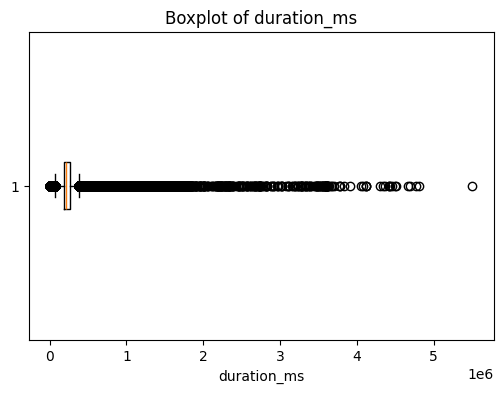

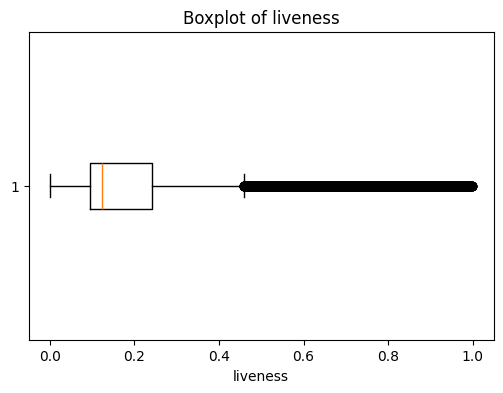

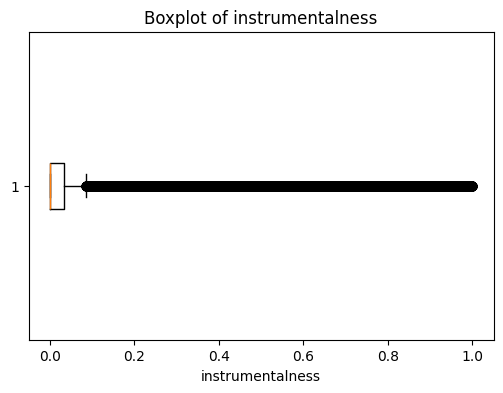

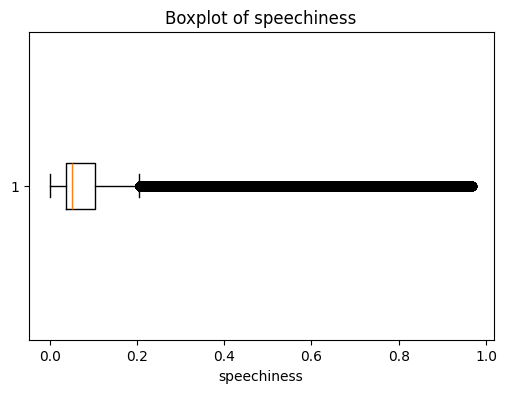

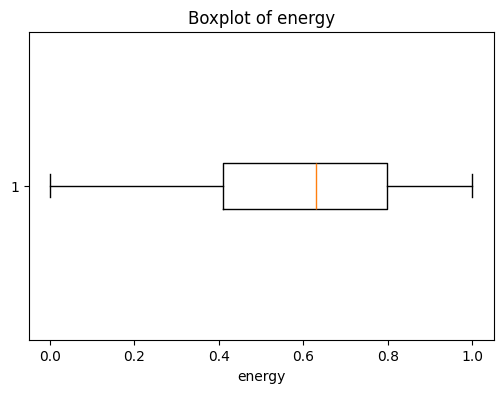

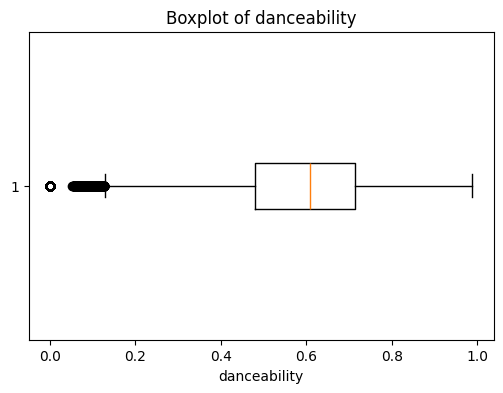

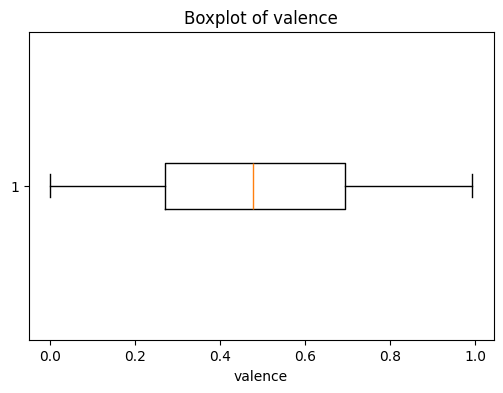

In [53]:
for feature in features:
    plt.figure(figsize=(6,4))
    plt.boxplot(data_tracks[feature], vert=False)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

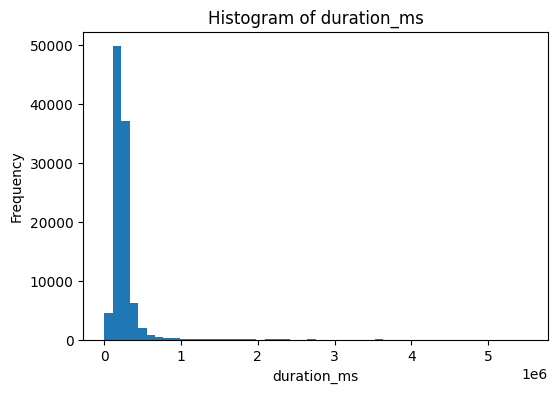

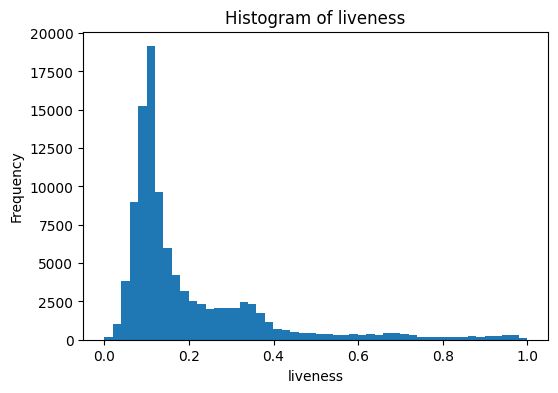

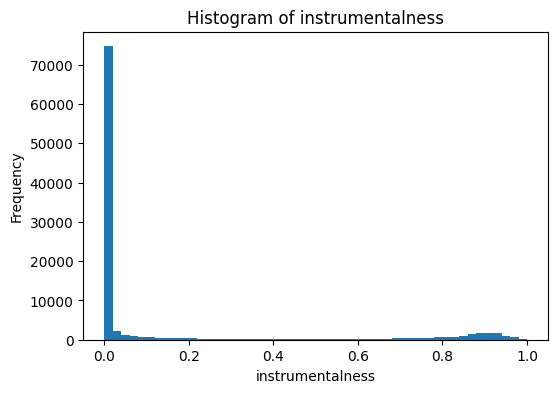

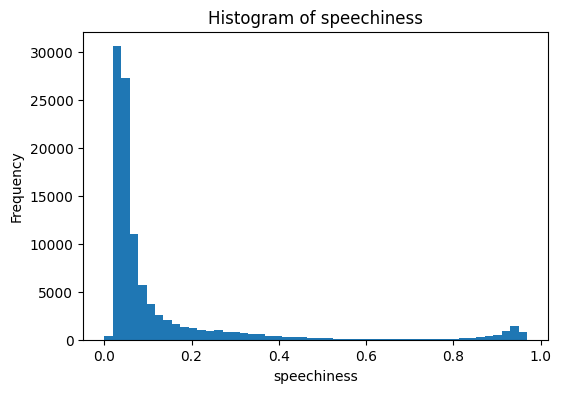

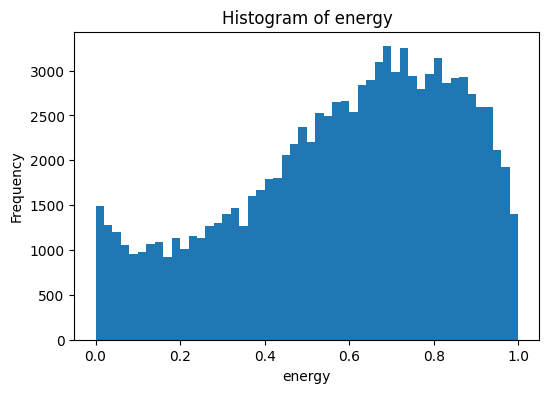

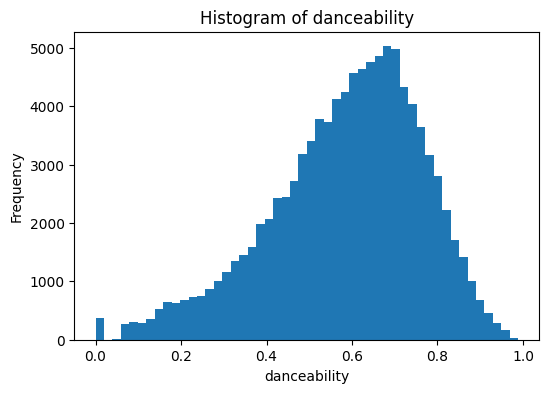

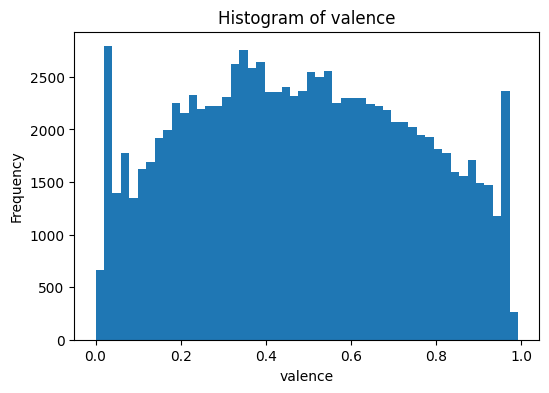

In [54]:
for feature in features:
    plt.figure(figsize=(6,4))
    plt.hist(data_tracks[feature], bins=50)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [55]:
features_high = ["duration_ms", "liveness", "speechiness"]
features_low = ["duration_ms", "speechiness", "instrumentalness", "energy", "danceability", "valence"]

# check highest values
for feature in features_high:
    print(f"\nTop values for {feature.upper()}:")
    display(
        data_tracks.sort_values(feature, ascending=False)[
            ["track_name", "artist_name", feature]
        ].head(10)
    )

# (optional) check lowest values for others
for feature in features_low:
    print(f"\nLowest values for {feature.upper()}:")
    display(
        data_tracks.sort_values(feature, ascending=True)[
            ["track_name", "artist_name", feature]
        ].head(10)
    )


Top values for DURATION_MS:


,track_name,artist_name,duration_ms
48041,A Guide to Men - Helen Rowland,DBS Audiobooks,5505831.0
76678,Introductory Lecture to Buddhism,Dalai Lama,4811520.0
95353,Stadium Hotel,King Dr. Saheed Osupa,4770973.0
36904,Thanksgiving,King Wasiu Ayinde,4694040.0
44351,The Letters & Journals Of Lord Nelson - Part 1,Charles Dance,4667397.0
7190,The Adventure of the Speckled Band,Sir Arthur Conan Doyle,4508318.0
51104,"Thunderstorm, Rain, Ocean Waves - Relaxing Sou...",Healing Sounds for Deep Sleep and Relaxation,4500037.0
7194,The Adventure of the Copper Beeches,Sir Arthur Conan Doyle,4462995.0
8370,The Adventure of the Beryl Coronet,Sir Arthur Conan Doyle,4437892.0
26806,Rag Lalit,Ram Narayan,4423000.0



Top values for LIVENESS:


,track_name,artist_name,liveness
64247,Et toute la ville en parle - En public,Michèle Torr,0.999
65606,Is This Love - Ao Vivo,Natiruts,0.999
43617,Jesús (feat. Marcos Witt),Marcos Witt,0.998
43008,Medley: E Ba Dupe F'oluwa / Sunny Loni Ariya -...,King Sunny Ade,0.998
69497,El Próximo Viernes - Live Version,Thalía,0.997
36815,Eres Suficiente,Danilo Montero,0.997
70551,Come Taste and See (Live),Red Rocks Worship,0.996
95412,Long Train Runnin' - Live,The Doobie Brothers,0.995
20493,Mueve Mueve,Juan Antonio Labra,0.994
42444,Lanterna dos Afogados,Maria Gadú,0.993



Top values for SPEECHINESS:


...

,track_name,artist_name,energy
60390,Pink Brown White Noise,Peninsulas,0.0
35006,Appliance With WN,University Of WN,0.0
46925,Tone Pan,BBVB,0.0
20477,Marchin' On,The Smashing Pumpkins,0.0
45894,White Noise: Turbines,Outside Broadcast Recordings,0.0
45887,Digistorm,René Watz,0.0
45854,L-R Noise,Lübecker,0.0
52186,Higher Freq Noise,Wavelength Minds,0.0
29806,Ground Support Electric Noise,Love Noise,0.0
52178,Dulled Noise Binaural,BBVB,0.0



Lowest values for DANCEABILITY:


,track_name,artist_name,danceability
13347,Sista varvet,Various Artists,0.0
39993,Introspective,Ogden Nash,0.0
3846,Legit Boss,Sasha Banks,0.0
37308,Bra jobbat!,Various Artists,0.0
22554,Feel The Glow,Naomi,0.0
37989,Varv tre,Various Artists,0.0
29330,Mixed Noises .wav,Noise Factory,0.0
18377,What Do You Call That? Would You Repeat That P...,Travelanguage,0.0
29326,Machine Repeating,Empty Fields,0.0
16107,Esto es Charles Ans,Various Artists,0.0



Lowest values for VALENCE:


,track_name,artist_name,valence
45877,Binaural Noise,University Of WN,0.0
90399,Reklame,Anders Matthesen,0.0
45863,Radio Frequency,Latium,0.0
30175,Transportation Please Call A Taxi,Travelanguage,0.0
30180,Please Drive Slower I Am In A Hurry,Travelanguage,0.0
30184,I Would Like This Pressed,Travelanguage,0.0
36001,Breanna Stewart - My Playlist,Various Artists,0.0
72924,Efterlysning,Anders Matthesen,0.0
30200,Yes No,Travelanguage,0.0
30204,Bread Butter,Travelanguage,0.0


In [56]:
for col in ["duration_ms", "speechiness"]:
    print(f"\n{col} percentiles:")
    print(data_tracks[col].quantile([0.90, 0.95, 0.99]))


duration_ms percentiles:
0.90    335635.8
0.95    420977.7
0.99    948365.2
Name: duration_ms, dtype: float64

speechiness percentiles:
0.90    0.302
0.95    0.730
0.99    0.947
Name: speechiness, dtype: float64


Most songs are approximately below 7 minutes. Most songs have speechines about 0.73. Liveness is decided to not be used as a filtering feature.

In [57]:
for col in ["duration_ms", "instrumentalness", "energy"]:
    print(f"\n{col} percentiles:")
    print(data_tracks[col].quantile([0.01, 0.05, 0.10]))


duration_ms percentiles:
0.01     57889.9
0.05    116467.9
0.10    150011.8
Name: duration_ms, dtype: float64

instrumentalness percentiles:
0.01    0.0
0.05    0.0
0.10    0.0
Name: instrumentalness, dtype: float64

energy percentiles:
0.01    0.012838
0.05    0.081900
0.10    0.183000
Name: energy, dtype: float64


Most songs are longer than 1 minute. At least 10% of the tracks have exactly 0 instrumentalness. Most tracks have energy higher than 0.08.

In [58]:
mask = (
    (data_tracks["energy"] == 0) &
    (data_tracks["instrumentalness"] == 0) &
    (data_tracks["speechiness"] == 0)
)

print(mask.sum())
print(mask.sum() / len(data_tracks))

31
0.00030410343440685116


> A small subset of tracks exhibited zero values across multiple audio features (energy, instrumentalness, and speechiness), which is inconsistent with typical musical recordings. These entries were treated as anomalous and removed from the dataset.

In [59]:
# Remove podcasts and short non-musical recordings using duration and speechiness.
data_tracks = data_tracks[
    (data_tracks["duration_ms"] > 60000) &
    (data_tracks["duration_ms"] < 600000) &
    (data_tracks["speechiness"] < 0.7)
]

# Remove white-noise / non-song entries that are simultaneously zero on energy,
# instrumentalness and speechiness. This filter is applied to data_tracks directly
# so that the fully cleaned dataframe is used consistently in every later step.
data_tracks = data_tracks[
    ~(
        (data_tracks["energy"] == 0) &
        (data_tracks["instrumentalness"] == 0) &
        (data_tracks["speechiness"] == 0)
    )
]

print(f"Rows after cleaning: {len(data_tracks)}")

Rows after cleaning: 94897


#### Data Profiling (Step 3)

In [60]:
data_tracks.info()

<class 'pandas.DataFrame'>
Index: 94897 entries, 0 to 101938
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   acousticness       94897 non-null  float64
 1   danceability       94897 non-null  float64
 2   duration_ms        94897 non-null  float64
 3   energy             94897 non-null  float64
 4   track_id           94897 non-null  str    
 5   instrumentalness   94897 non-null  float64
 6   key                94897 non-null  float64
 7   liveness           94897 non-null  float64
 8   loudness           94897 non-null  float64
 9   mode               94897 non-null  float64
 10  track_name         94897 non-null  str    
 11  track_popularity   94897 non-null  float64
 12  speechiness        94897 non-null  float64
 13  tempo              94897 non-null  float64
 14  time_signature     94897 non-null  float64
 15  valence            94897 non-null  float64
 16  artist_id          94897 non-null  st

In [61]:
data_tracks.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,track_popularity,speechiness,tempo,time_signature,valence,artist_popularity
count,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000,94897.000000
mean,0.328860,0.586835,229858.620420,0.603762,0.152902,5.271568,0.188527,-8.871668,0.615509,41.447127,0.085914,119.688370,3.905255,0.487909,49.425514
std,0.328315,0.176866,73011.544225,0.251511,0.306968,3.571904,0.164464,5.700486,0.486477,15.696746,0.093591,29.321975,0.429913,0.262726,19.573700
min,0.000000,0.000000,60013.000000,0.000018,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.034300,0.477000,186147.000000,0.444000,0.000000,2.000000,0.094500,-10.351000,0.000000,31.000000,0.035800,97.380000,4.000000,0.273000,36.000000
50%,0.204000,0.607000,216955.000000,0.645000,0.000060,5.000000,0.121000,-7.325000,1.000000,42.000000,0.048500,119.937000,4.000000,0.483000,51.000000
75%,0.589000,0.718000,257480.000000,0.805000,0.044500,8.000000,0.225000,-5.380000,1.000000,52.000000,0.087100,137.184000,4.000000,0.702000,64.000000
max,0.996000,0.989000,599786.000000,1.000000,1.000000,11.000000,0.999000,2.719000,1.000000,97.000000,0.699000,244.035000,5.000000,0.993000,100.000000


In [62]:
data_tracks.skew(numeric_only=True)

acousticness         0.718144
danceability        -0.532657
duration_ms          1.433665
energy              -0.579037
instrumentalness     1.775258
key                 -0.000282
liveness             2.405667
loudness            -2.348408
mode                -0.474891
track_popularity    -0.067995
speechiness          2.826677
tempo                0.347456
time_signature      -4.053644
valence              0.052328
artist_popularity   -0.178999
dtype: float64

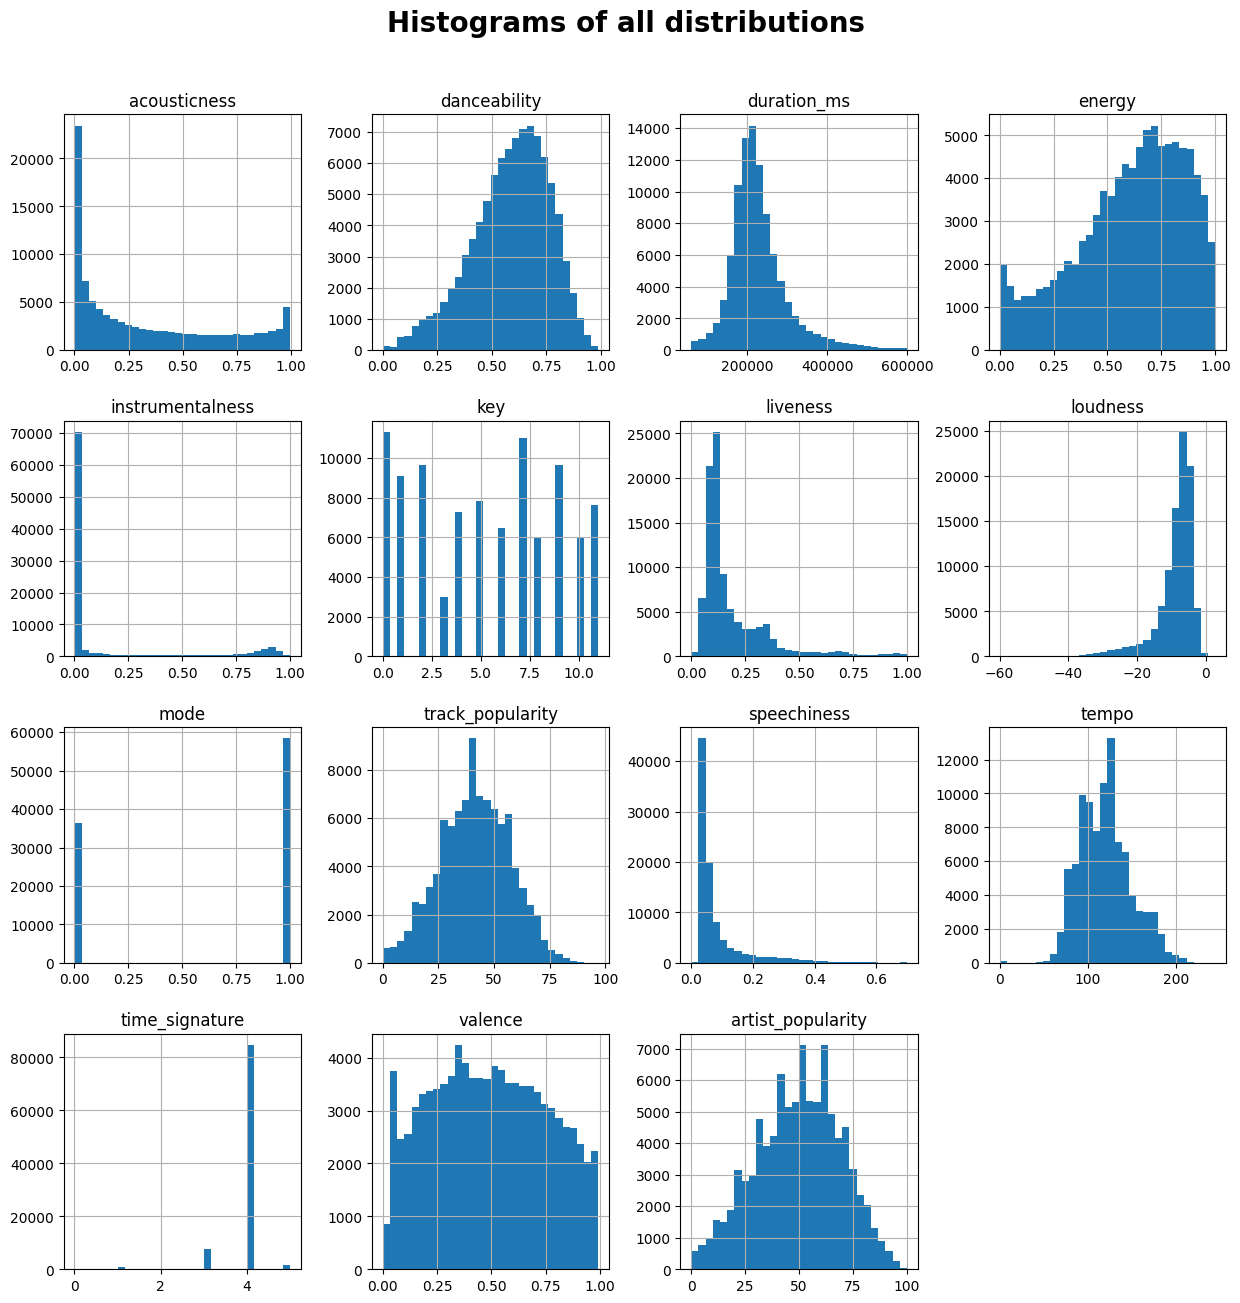

<Figure size 640x480 with 0 Axes>

In [63]:
data_tracks.drop(columns=["track_id", "track_name", "artist_id", "artist_name"]).hist(figsize=(15,15), bins=30)
plt.suptitle('Histograms of all distributions', y=0.95, fontsize=20, fontweight='semibold')

plt.show()
plt.subplots_adjust(hspace=0.5)

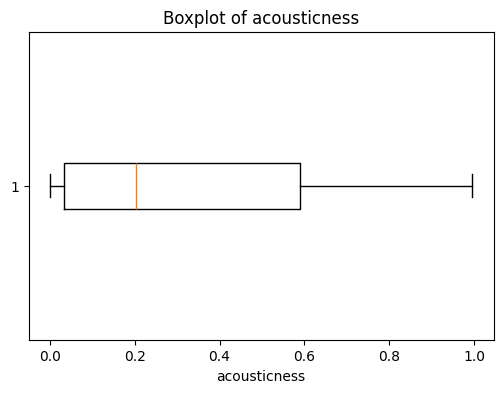

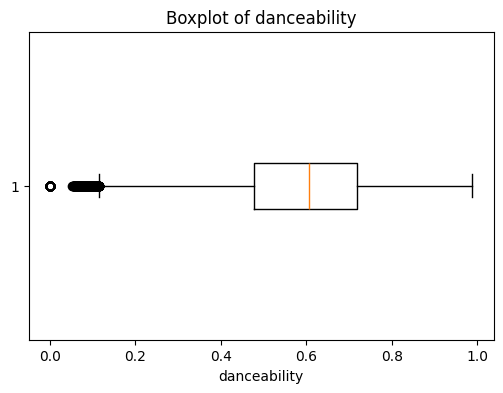

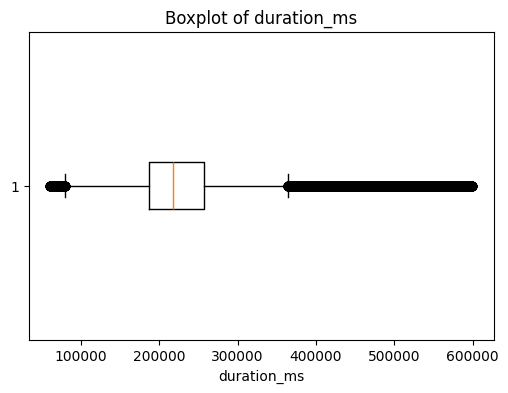

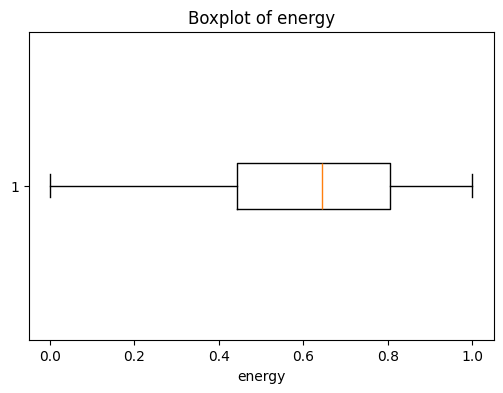

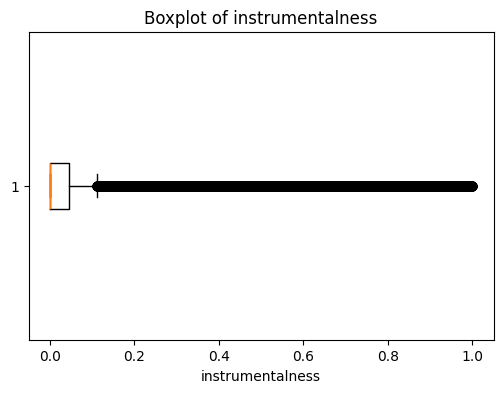

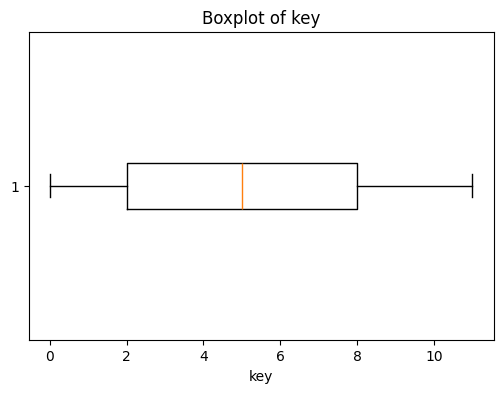

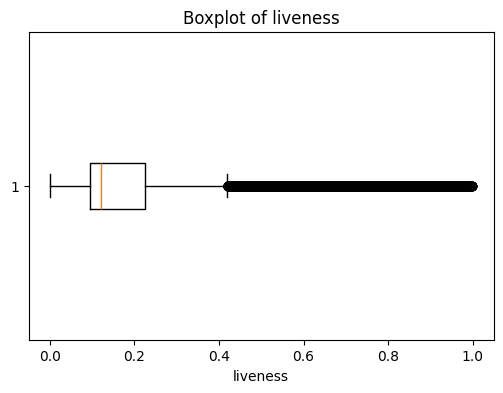

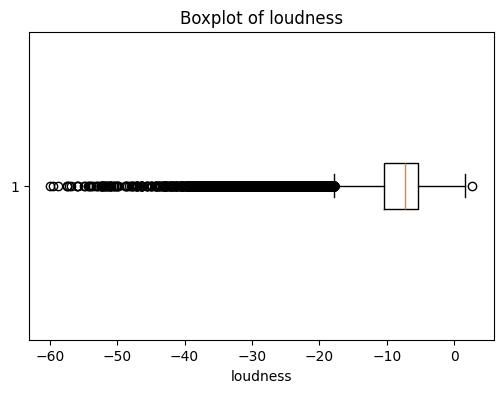

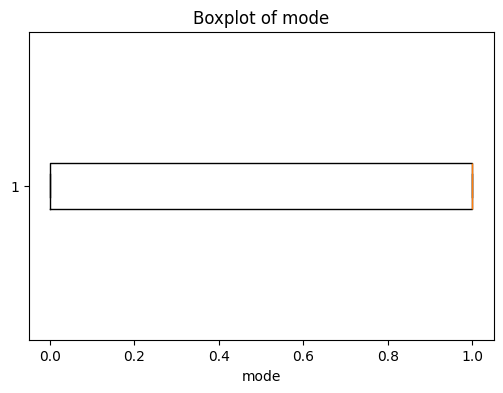

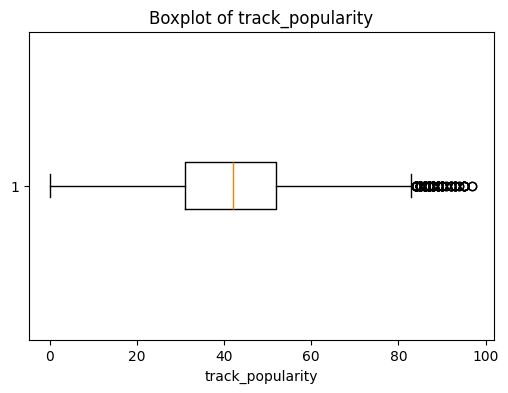

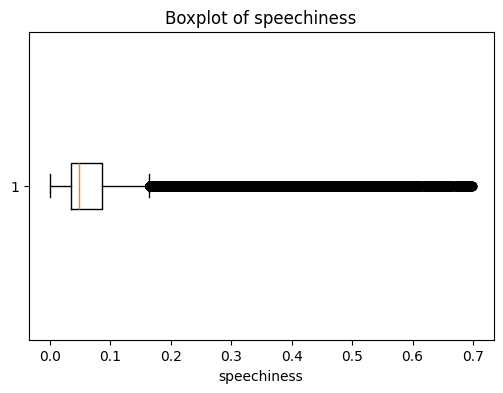

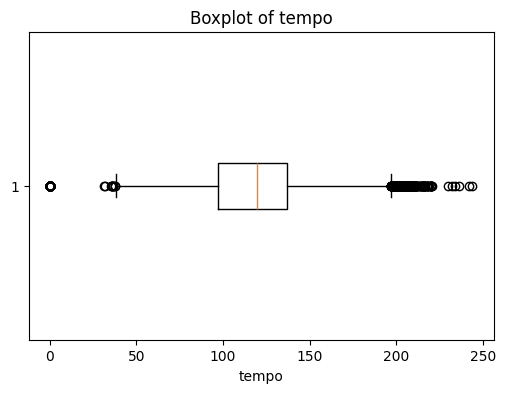

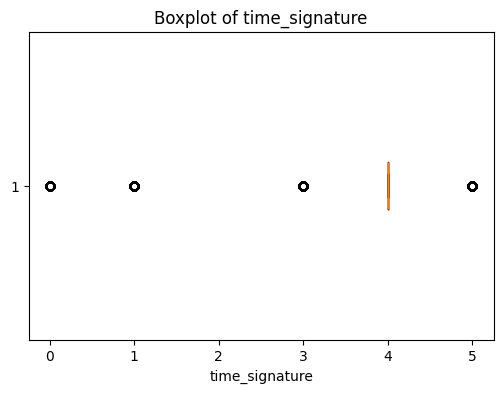

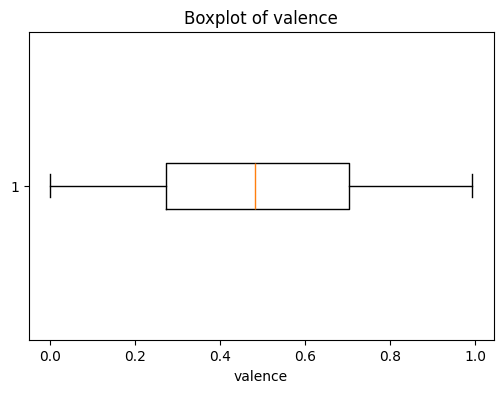

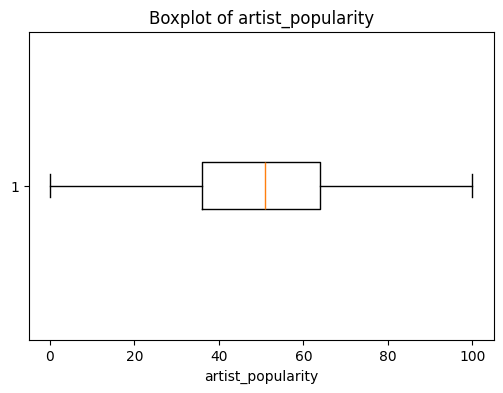

In [64]:
all_features = ["acousticness","danceability","duration_ms","energy","instrumentalness","key","liveness","loudness","mode","track_popularity","speechiness","tempo","time_signature","valence","artist_popularity"]

for feature in all_features:
    plt.figure(figsize=(6,4))
    plt.boxplot(data_tracks[feature], vert=False)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

**Key is the estimated overall key of the track**
- It uses standard Pitch Class notation, where integers correspond to specific pitches (e.g., 0 = C, 1 = C♯/D♭, 2 = D)
- If the system cannot detect a key, it assigns a value of -1

**Mode indicates the modality (major or minor) of a song, which determines the type of scale used for its melody.**
- In the dataset, Major is represented by 1 and Minor is represented by 0

**Time_signature is an estimated overall meter of a track**
- It is a convention that specifies how many beats are contained in each bar (or measure)

**Valence is a measure ranging from 0.0 to 1.0 that describes the musical positiveness conveyed by a song**
- Tracks with high valence sound more positive (e.g., happy, cheerful, or euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, or angry)

#### Naive Baseline (Step 4)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = data_tracks["track_popularity"]

# baseline prediction
mean_popularity = y_true.mean()
y_pred_baseline = np.full(len(y_true), mean_popularity)

# metrics
mae = mean_absolute_error(y_true, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
r2 = r2_score(y_true, y_pred_baseline)

print("Baseline Performance:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

Baseline Performance:
MAE: 12.657
RMSE: 15.697
R²: 0.000


The performance of the regression models is evaluated using Mean Absolute Error (MAE) and the coefficient of determination (R²). MAE provides an interpretable measure of the average prediction error, while R² evaluates how well the model explains the variability in the target variable. These two metrics complement each other by capturing both prediction accuracy and explanatory power.

As a baseline, a naive model is constructed by predicting the mean track popularity for all observations. This baseline represents the best constant prediction in the absence of feature information. The baseline model yields an R² score close to zero, indicating that it does not explain any variability in the data. Therefore, any meaningful model should outperform this baseline in both MAE and R².

## Final Phase: Answering the Research Questions

In this phase two complementary approaches are used. **(1) Hypothesis testing** is applied to the statistical research question (the association between artist_popularity and track_popularity). **(2) Machine-learning modelling** is applied to the predictive research question, comparing at least two regression models against the naive baseline, with hyperparameter tuning, statistical comparison of errors, and interpretability analysis.

#### Feature Selection and Generation (Step 5)

The candidate predictors are the nine high-level audio features plus artist_popularity. The discrete metadata fields key, mode and time_signature are excluded because they are categorical pitch/meter codes rather than perceptual descriptors and carry little information for a regression on a continuous target. First, the contribution of each predictor is screened with a Spearman correlation against the target and with a model-based (Random Forest) importance ranking. Redundancy among predictors is assessed with a Pearson correlation matrix. Then two new features are generated and evaluated for added value.

In [66]:
# Imports and configuration for the modelling phase
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

RANDOM_STATE = 42
FIGDIR = "../reports/figures"
plt.rcParams.update({"savefig.dpi": 350, "savefig.bbox": "tight"})

AUDIO_FEATURES = ["acousticness", "danceability", "energy", "instrumentalness",
                  "liveness", "loudness", "speechiness", "tempo", "valence"]
FEATURES = AUDIO_FEATURES + ["artist_popularity"]
TARGET = "track_popularity"
print("Predictors:", FEATURES)
print("Target    :", TARGET)

Predictors: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'artist_popularity']
Target    : track_popularity


In [67]:
# Spearman correlation of each predictor with the target (rank-based: robust to non-linearity)
corr_with_target = (data_tracks[FEATURES + [TARGET]]
                    .corr(method="spearman")[TARGET].drop(TARGET)
                    .sort_values(key=lambda s: s.abs(), ascending=False))
print("Spearman correlation with track_popularity:")
print(corr_with_target.round(3))

Spearman correlation with track_popularity:
artist_popularity    0.665
loudness             0.130
instrumentalness    -0.123
danceability         0.101
acousticness        -0.031
energy               0.026
liveness            -0.022
speechiness          0.006
valence             -0.001
tempo               -0.000
Name: track_popularity, dtype: float64


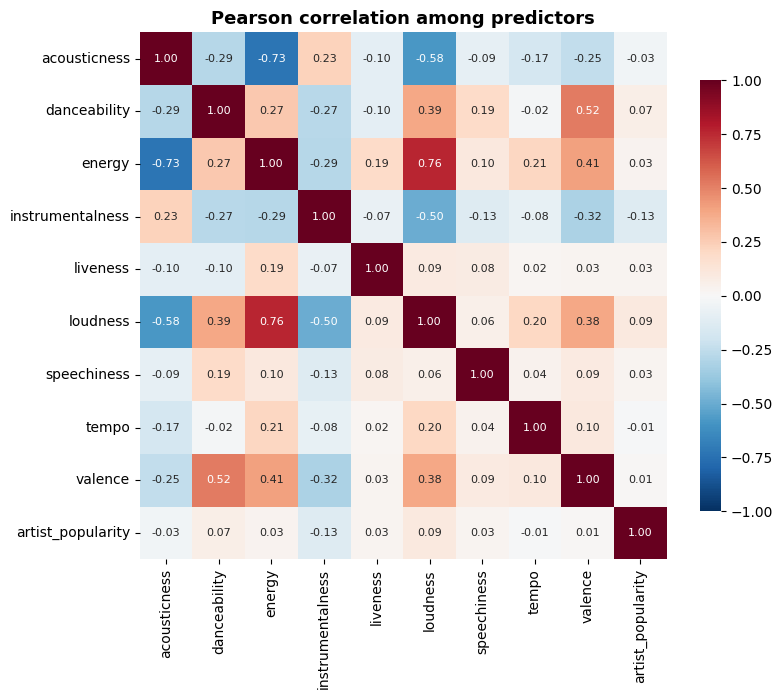

Predictor pairs with |r| >= 0.5 (redundancy):
  acousticness - energy: r = -0.73
  acousticness - loudness: r = -0.58
  danceability - valence: r = 0.52
  energy - loudness: r = 0.76


In [68]:
# Redundancy among predictors (Pearson correlation matrix)
corr_matrix = data_tracks[FEATURES].corr(method="pearson")
plt.figure(figsize=(8.5, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8},
            annot_kws={"size": 8})
plt.title("Pearson correlation among predictors", fontsize=13, fontweight="semibold")
plt.savefig(f"{FIGDIR}/fig_corr_heatmap.png", dpi=350)
plt.show()

# report strongly correlated (redundant) pairs
redundant = [(corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 2))
             for i in range(len(corr_matrix)) for j in range(i + 1, len(corr_matrix))
             if abs(corr_matrix.iloc[i, j]) >= 0.5]
print("Predictor pairs with |r| >= 0.5 (redundancy):")
for a, b, r in redundant:
    print(f"  {a} - {b}: r = {r}")

In [69]:
# Model-based feature-importance screen (Random Forest on a 15k subsample)
screen_sample = data_tracks.sample(15000, random_state=RANDOM_STATE)
rf_screen = RandomForestRegressor(n_estimators=120, min_samples_leaf=5,
                                  random_state=RANDOM_STATE)
rf_screen.fit(screen_sample[FEATURES], screen_sample[TARGET])
screen_importance = (pd.Series(rf_screen.feature_importances_, index=FEATURES)
                     .sort_values(ascending=False))
print("Random Forest importance (feature-selection screen):")
print(screen_importance.round(3))

Random Forest importance (feature-selection screen):
artist_popularity    0.601
loudness             0.052
speechiness          0.048
valence              0.046
acousticness         0.045
liveness             0.044
danceability         0.044
tempo                0.041
energy               0.040
instrumentalness     0.039
dtype: float64


**Feature generation.** Two new features are created. log_duration is a log transform of duration_ms, which is strongly right-skewed; the transform compresses the long tail so the feature is usable by scale-sensitive linear models. mood_index is an aggregated, standardized average of valence, energy and danceability — a single "upbeat / positive" descriptor motivated by the perceptual grouping of these features. Their added predictive value is tested by comparing a Random Forest trained with and without them.

In [70]:
# Generate features
data_tracks["log_duration"] = np.log1p(data_tracks["duration_ms"])
z = lambda s: (s - s.mean()) / s.std()
data_tracks["mood_index"] = (z(data_tracks["valence"])
                             + z(data_tracks["energy"])
                             + z(data_tracks["danceability"])) / 3
GENERATED = ["log_duration", "mood_index"]

for g in GENERATED:
    rho, p = stats.spearmanr(data_tracks[g], data_tracks[TARGET])
    print(f"{g}: Spearman rho = {rho:.3f} (p = {p:.1e})")

# Added-value check on a 15k subsample (test R2 with vs without generated features)
s = data_tracks.sample(15000, random_state=RANDOM_STATE)
Xa, Xb, ya, yb = train_test_split(s, s[TARGET], test_size=.25, random_state=RANDOM_STATE)
def _quick_r2(cols):
    m = RandomForestRegressor(n_estimators=120, min_samples_leaf=5,
                              random_state=RANDOM_STATE).fit(Xa[cols], ya)
    return r2_score(yb, m.predict(Xb[cols]))
r2_base = _quick_r2(FEATURES)
r2_gen = _quick_r2(FEATURES + GENERATED)
print(f"\nTest R2  base = {r2_base:.4f}   base + generated = {r2_gen:.4f}   "
      f"delta = {r2_gen - r2_base:+.4f}")

log_duration: Spearman rho = -0.059 (p = 5.5e-75)
mood_index: Spearman rho = 0.053 (p = 9.9e-60)

Test R2  base = 0.5072   base + generated = 0.5149   delta = +0.0077


The generated features correlate only weakly with the target and improve R² by a negligible amount, so they are **not** carried into the final models; the ten original predictors are retained. **Preprocessing:** the predictors are on very different scales (tempo in BPM, loudness in dB, the others in [0,1]), so for the scale-sensitive linear models the features are standardized with StandardScaler inside a pipeline. Tree-based models are scale-invariant and use the raw features.

#### Hypothesis Test and Initial Models (Step 6)

**Statistical research question.** *Is there a statistically significant relationship between artist popularity and track popularity?*

- **Variables:** artist_popularity (X) and track_popularity (Y), both continuous integer scores in [0,100].
- **H0:** there is no monotonic/linear association between artist_popularity and track_popularity (population correlation = 0).
- **H1:** there is a non-zero association (correlation ≠ 0).
- **Significance level:** α = 0.05.

Both variables are close to symmetric, so a Pearson correlation is appropriate; a Spearman rank correlation is also reported because it does not assume linearity and is robust to the bounded scale.

In [71]:
# Assumption screen + correlation tests
ap, tp = data_tracks["artist_popularity"], data_tracks[TARGET]
print(f"Skewness  artist_popularity = {ap.skew():.3f}   track_popularity = {tp.skew():.3f}")

pearson_r, pearson_p = stats.pearsonr(ap, tp)
spearman_r, spearman_p = stats.spearmanr(ap, tp)
print(f"Pearson  r   = {pearson_r:.4f}   p = {pearson_p:.3e}")
print(f"Spearman rho = {spearman_r:.4f}   p = {spearman_p:.3e}")
print("Decision:", "reject H0" if pearson_p < 0.05 else "fail to reject H0",
      "at alpha = 0.05")

Skewness  artist_popularity = -0.179   track_popularity = -0.068
Pearson  r   = 0.6832   p = 0.000e+00
Spearman rho = 0.6646   p = 0.000e+00
Decision: reject H0 at alpha = 0.05


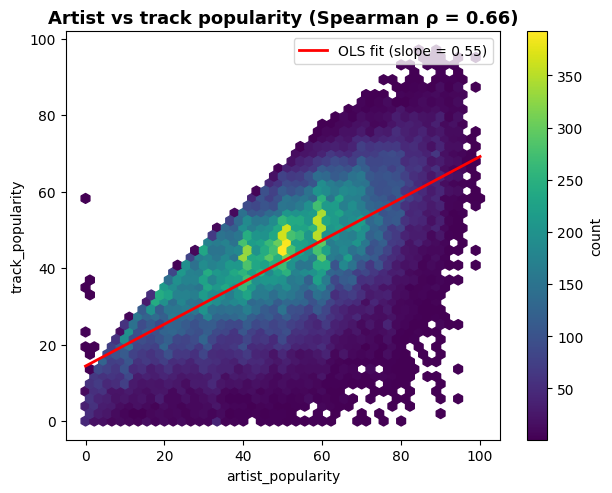

In [72]:
# Visualize the relationship (hexbin density + OLS trend line)
plt.figure(figsize=(7, 5.3))
hb = plt.hexbin(ap, tp, gridsize=45, cmap="viridis", mincnt=1)
plt.colorbar(hb, label="count")
slope, intercept = np.polyfit(ap, tp, 1)
xs = np.linspace(ap.min(), ap.max(), 100)
plt.plot(xs, intercept + slope * xs, color="red", lw=2, label=f"OLS fit (slope = {slope:.2f})")
plt.xlabel("artist_popularity"); plt.ylabel("track_popularity")
plt.title(f"Artist vs track popularity (Spearman ρ = {spearman_r:.2f})",
          fontsize=13, fontweight="semibold")
plt.legend()
plt.savefig(f"{FIGDIR}/fig_artist_vs_track.png", dpi=350)
plt.show()

**Modelling setup.** The data are split into training (60%), validation (20%) and test (20%) sets. The training set fits the models, the validation set selects hyperparameters, and the test set is held out for final evaluation only. As required, the naive baseline predicts the mean track_popularity for every observation. The initial (untuned) Linear Regression and Random Forest are then evaluated on the test set before any tuning.

In [73]:
# 60 / 20 / 20 train / validation / test split
X, y = data_tracks[FEATURES], data_tracks[TARGET]
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=.25,
                                                  random_state=RANDOM_STATE)
print(f"train = {len(X_train)}   val = {len(X_val)}   test = {len(X_test)}")

def scores(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred)}

# Naive baseline (mean of train+val)
y_trainval = pd.concat([y_train, y_val])
naive_pred = np.full(len(y_test), y_trainval.mean())

# Initial untuned models (fit on train, evaluate on test)
lin_init = Pipeline([("scaler", StandardScaler()),
                     ("model", LinearRegression())]).fit(X_train, y_train)
rf_init = RandomForestRegressor(n_estimators=100,
                                random_state=RANDOM_STATE).fit(X_train, y_train)

print("\nInitial test-set performance (before tuning):")
for name, pred in [("Naive (mean)", naive_pred),
                   ("Linear Regression", lin_init.predict(X_test)),
                   ("Random Forest", rf_init.predict(X_test))]:
    s = scores(y_test, pred)
    print(f"  {name:20s}  MAE={s['MAE']:.3f}  RMSE={s['RMSE']:.3f}  R2={s['R2']:.3f}")

train = 56937   val = 18980   test = 18980

Initial test-set performance (before tuning):
  Naive (mean)          MAE=12.567  RMSE=15.585  R2=-0.000
  Linear Regression     MAE=8.909  RMSE=11.267  R2=0.477
  Random Forest         MAE=8.559  RMSE=10.894  R2=0.511


#### Hyperparameter Tuning (Step 7)

Each model is tuned on the **validation** set (test set untouched).

- **Linear model.** Ordinary least squares has no hyperparameters; a regularized **Ridge** variant is therefore tuned over the regularization strength alpha to check whether shrinkage helps. Because the number of observations greatly exceeds the number of predictors, little regularization is expected to be needed.
- **Random Forest.** The parameters that control model complexity and overfitting are tuned: n_estimators (number of trees), max_depth, min_samples_split and min_samples_leaf. Candidate configurations are fit on the training set and ranked by validation MAE.

In [74]:
# Ridge regularization-strength tuning (validation MAE)
ridge_alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_val = {}
for a in ridge_alphas:
    m = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=a))]).fit(X_train, y_train)
    ridge_val[a] = mean_absolute_error(y_val, m.predict(X_val))
best_alpha = min(ridge_val, key=ridge_val.get)
print("Ridge validation MAE by alpha:")
for a, v in ridge_val.items():
    print(f"  alpha={a:<7} MAE={v:.4f}")
print("Best alpha:", best_alpha)

Ridge validation MAE by alpha:
  alpha=0.01    MAE=8.9871
  alpha=0.1     MAE=8.9871
  alpha=1       MAE=8.9871
  alpha=10      MAE=8.9871
  alpha=100     MAE=8.9872
  alpha=1000    MAE=8.9889
Best alpha: 0.01


In [75]:
# Random Forest grid (fit on a 15k training subsample, ranked on the full validation set)
rf_grid = [(120, None, 2, 1), (120, None, 2, 5), (120, None, 10, 5),
           (120, 20, 5, 5), (120, 16, 10, 10), (150, 12, 10, 20)]
X_train_s = X_train.sample(15000, random_state=RANDOM_STATE)
y_train_s = y_train.loc[X_train_s.index]

rf_results = []
for n_est, depth, mss, msl in rf_grid:
    m = RandomForestRegressor(n_estimators=n_est, max_depth=depth, min_samples_split=mss,
                              min_samples_leaf=msl, random_state=RANDOM_STATE).fit(X_train_s, y_train_s)
    pv = m.predict(X_val)
    rf_results.append({"n_estimators": n_est, "max_depth": depth, "min_samples_split": mss,
                       "min_samples_leaf": msl, "val_MAE": round(mean_absolute_error(y_val, pv), 4),
                       "val_R2": round(r2_score(y_val, pv), 4)})
rf_grid_df = pd.DataFrame(rf_results).sort_values("val_MAE").reset_index(drop=True)
best_rf_cfg = rf_grid_df.iloc[0].to_dict()
display(rf_grid_df)
print("Best RF configuration (lowest validation MAE):")
print(best_rf_cfg)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,val_MAE,val_R2
0,120,16.0,10,10,8.7764,0.5017
1,120,20.0,5,5,8.7887,0.4999
2,120,NaN,10,5,8.7914,0.4996
3,120,NaN,2,5,8.7914,0.4996
4,150,12.0,10,20,8.7966,0.5001
5,120,NaN,2,1,8.8228,0.4946


Best RF configuration (lowest validation MAE):
{'n_estimators': 120.0, 'max_depth': 16.0, 'min_samples_split': 10.0, 'min_samples_leaf': 10.0, 'val_MAE': 8.7764, 'val_R2': 0.5017}


#### Comparison with Baselines (Step 8)

The tuned models are retrained on the combined training+validation data and evaluated on the held-out test set, alongside the naive baseline and the untuned models. Whether the differences in prediction error are statistically significant is then tested with paired tests on the per-track absolute errors over the same test observations (Wilcoxon signed-rank, which makes no normality assumption, with a paired t-test reported alongside).

In [76]:
# Retrain tuned models on train+val; collect test predictions
X_trainval = pd.concat([X_train, X_val])

ridge_best = Pipeline([("scaler", StandardScaler()),
                       ("model", Ridge(alpha=best_alpha))]).fit(X_trainval, y_trainval)
rf_best = RandomForestRegressor(n_estimators=int(best_rf_cfg["n_estimators"]),
                                max_depth=None if pd.isna(best_rf_cfg["max_depth"]) else int(best_rf_cfg["max_depth"]),
                                min_samples_split=int(best_rf_cfg["min_samples_split"]),
                                min_samples_leaf=int(best_rf_cfg["min_samples_leaf"]),
                                random_state=RANDOM_STATE).fit(X_trainval, y_trainval)
ols_final = Pipeline([("scaler", StandardScaler()),
                      ("model", LinearRegression())]).fit(X_trainval, y_trainval)

preds = {"Naive (mean)": naive_pred,
         "Linear Reg (OLS)": ols_final.predict(X_test),
         "Ridge (tuned)": ridge_best.predict(X_test),
         "Random Forest (tuned)": rf_best.predict(X_test)}
print("tuned models retrained on train+val.")

tuned models retrained on train+val.


In [77]:
# Retrain the untuned Random Forest on train+val and build the comparison table
rf_untuned = RandomForestRegressor(n_estimators=100,
                                   random_state=RANDOM_STATE).fit(X_trainval, y_trainval)
preds["Random Forest (untuned)"] = rf_untuned.predict(X_test)

order = ["Naive (mean)", "Linear Reg (OLS)", "Ridge (tuned)",
         "Random Forest (untuned)", "Random Forest (tuned)"]
results_df = pd.DataFrame({name: scores(y_test, preds[name]) for name in order}).T
results_df = results_df[["MAE", "RMSE", "R2"]].round(3)
display(results_df)

,MAE,RMSE,R2
Naive (mean),12.567,15.585,-0.000
Linear Reg (OLS),8.912,11.266,0.477
Ridge (tuned),8.912,11.266,0.477
Random Forest (untuned),8.561,10.894,0.511
Random Forest (tuned),8.491,10.794,0.520


In [78]:
# Paired significance tests on absolute errors (same test observations)
abs_err = {name: np.abs(y_test.values - p) for name, p in preds.items()}
def paired_test(a, b):
    w = stats.wilcoxon(abs_err[a], abs_err[b])
    t = stats.ttest_rel(abs_err[a], abs_err[b])
    return w.pvalue, t.pvalue
comparisons = [("Random Forest (tuned)", "Naive (mean)"),
               ("Random Forest (tuned)", "Linear Reg (OLS)"),
               ("Linear Reg (OLS)", "Naive (mean)"),
               ("Random Forest (tuned)", "Random Forest (untuned)"),
               ("Ridge (tuned)", "Linear Reg (OLS)")]
print("Paired comparison of absolute errors:")
for a, b in comparisons:
    wp, tp_ = paired_test(a, b)
    print(f"  {a:24s} vs {b:24s}  Wilcoxon p={wp:.2e}  t-test p={tp_:.2e}")

Paired comparison of absolute errors:
  Random Forest (tuned)    vs Naive (mean)              Wilcoxon p=0.00e+00  t-test p=0.00e+00
  Random Forest (tuned)    vs Linear Reg (OLS)          Wilcoxon p=9.68e-54  t-test p=1.50e-83
  Linear Reg (OLS)         vs Naive (mean)              Wilcoxon p=0.00e+00  t-test p=0.00e+00
  Random Forest (tuned)    vs Random Forest (untuned)   Wilcoxon p=1.44e-07  t-test p=3.40e-07
  Ridge (tuned)            vs Linear Reg (OLS)          Wilcoxon p=5.32e-01  t-test p=6.25e-01


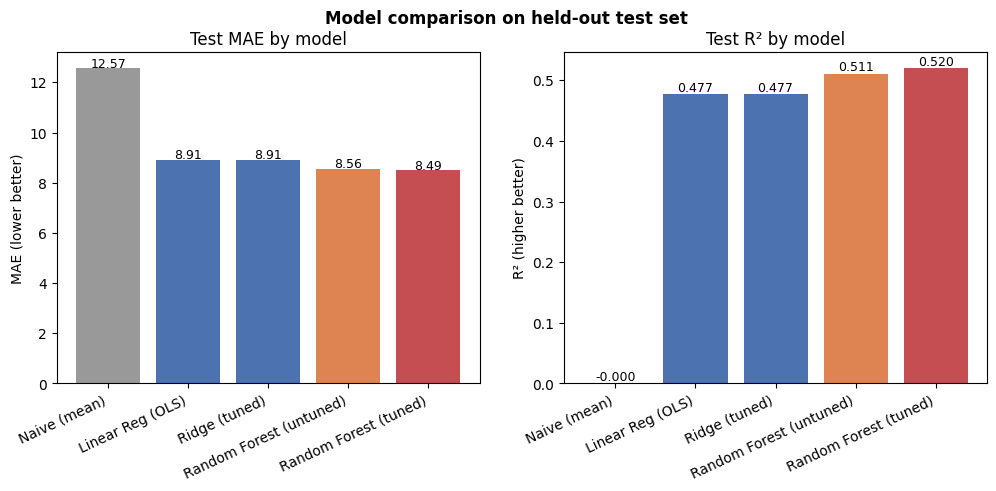

In [79]:
# Model comparison bar chart
mae_vals = [results_df.loc[k, "MAE"] for k in order]
r2_vals = [results_df.loc[k, "R2"] for k in order]
colors = ["#999999", "#4C72B0", "#4C72B0", "#DD8452", "#C44E52"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].bar(range(len(order)), mae_vals, color=colors)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=25, ha="right")
ax[0].set_ylabel("MAE (lower better)"); ax[0].set_title("Test MAE by model")
for i, v in enumerate(mae_vals): ax[0].text(i, v + .05, f"{v:.2f}", ha="center", fontsize=9)
ax[1].bar(range(len(order)), r2_vals, color=colors)
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels(order, rotation=25, ha="right")
ax[1].set_ylabel("R² (higher better)"); ax[1].set_title("Test R² by model")
for i, v in enumerate(r2_vals): ax[1].text(i, v + .005, f"{v:.3f}", ha="center", fontsize=9)
fig.suptitle("Model comparison on held-out test set", fontweight="semibold")
plt.savefig(f"{FIGDIR}/fig_model_comparison.png", dpi=350)
plt.show()

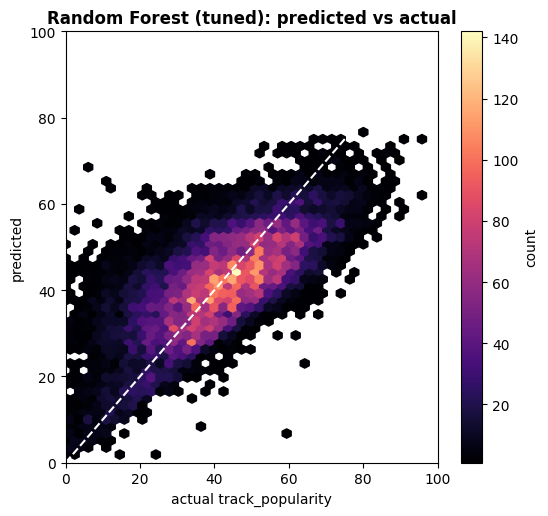

In [80]:
# Predicted vs actual for the best model
yp = preds["Random Forest (tuned)"]
plt.figure(figsize=(6, 5.6))
plt.hexbin(y_test, yp, gridsize=40, cmap="magma", mincnt=1)
plt.colorbar(label="count")
plt.plot([0, 100], [0, 100], "w--", lw=1.5)
plt.xlabel("actual track_popularity"); plt.ylabel("predicted")
plt.title("Random Forest (tuned): predicted vs actual", fontsize=12, fontweight="semibold")
plt.xlim(0, 100); plt.ylim(0, 100)
plt.savefig(f"{FIGDIR}/fig_pred_vs_actual.png", dpi=350)
plt.show()

#### Interpretability Analysis (Step 9)

Two complementary importance measures are computed for the tuned Random Forest: impurity-based importance (how much each feature reduces variance across the trees) and permutation importance on the test set (how much test R² drops when a feature's values are shuffled). The goal is to determine whether the model relies mainly on artist_popularity or on the track-level audio features, which directly addresses the artist-vs-audio research question.

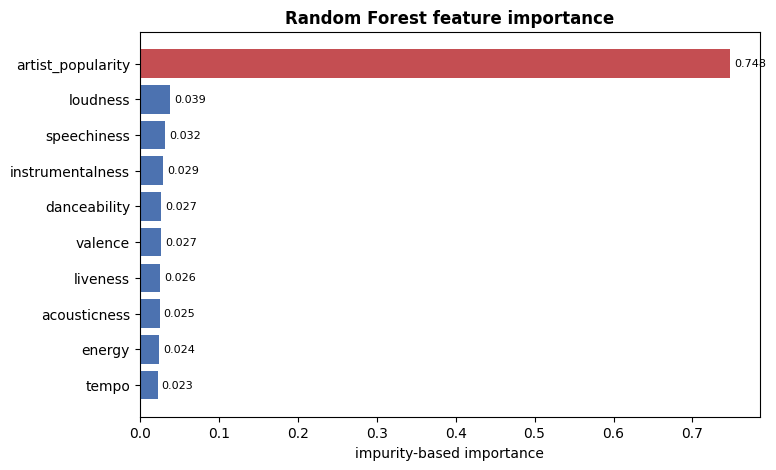

artist_popularity accounts for 74.8% of total impurity importance; all audio features together for 25.2%.


In [81]:
# Impurity-based feature importance
importance = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(8, 5))
bar_colors = ["#C44E52" if f == "artist_popularity" else "#4C72B0" for f in importance.index]
plt.barh(range(len(importance)), importance.values, color=bar_colors)
plt.yticks(range(len(importance)), importance.index)
plt.xlabel("impurity-based importance")
plt.title("Random Forest feature importance", fontweight="semibold")
for i, v in enumerate(importance.values):
    plt.text(v + .005, i, f"{v:.3f}", va="center", fontsize=8)
plt.savefig(f"{FIGDIR}/fig_rf_importance.png", dpi=350)
plt.show()

artist_share = importance["artist_popularity"] / importance.sum()
print(f"artist_popularity accounts for {artist_share:.1%} of total impurity importance; "
      f"all audio features together for {1 - artist_share:.1%}.")

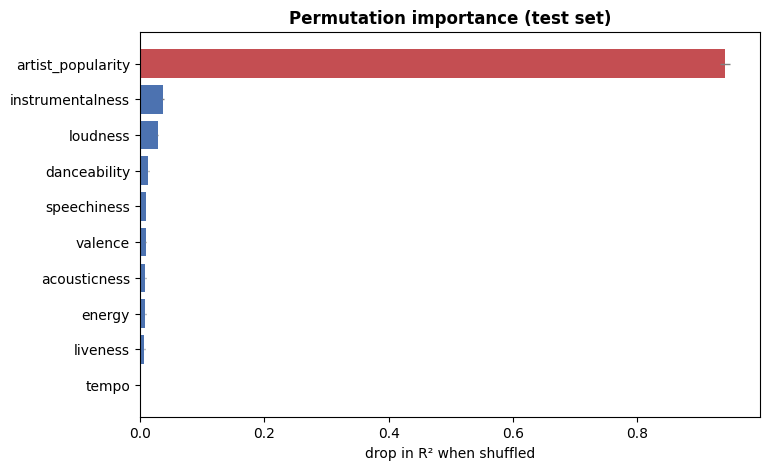

artist_popularity    0.941
instrumentalness     0.037
loudness             0.029
danceability         0.014
speechiness          0.011
valence              0.010
acousticness         0.009
energy               0.009
liveness             0.007
tempo                0.002
dtype: float64


In [82]:
# Permutation importance on a test subsample
perm_idx = X_test.sample(9000, random_state=RANDOM_STATE).index
perm = permutation_importance(rf_best, X_test.loc[perm_idx], y_test.loc[perm_idx],
                              n_repeats=6, random_state=RANDOM_STATE, scoring="r2")
perm_mean = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
perm_std = pd.Series(perm.importances_std, index=FEATURES)
plt.figure(figsize=(8, 5))
bar_colors = ["#C44E52" if f == "artist_popularity" else "#4C72B0" for f in perm_mean.index]
plt.barh(range(len(perm_mean)), perm_mean.values,
         xerr=perm_std.loc[perm_mean.index].values, color=bar_colors,
         error_kw=dict(ecolor="gray", lw=1))
plt.yticks(range(len(perm_mean)), perm_mean.index)
plt.xlabel("drop in R² when shuffled")
plt.title("Permutation importance (test set)", fontweight="semibold")
plt.savefig(f"{FIGDIR}/fig_perm_importance.png", dpi=350)
plt.show()
print(perm_mean.sort_values(ascending=False).round(3))

#### Implications of the Study (Step 10)

The results give a clear and somewhat one-sided answer. artist_popularity is by far the strongest signal: it alone reaches a Spearman correlation of about 0.66 with track popularity, accounts for roughly three quarters of the Random Forest's impurity importance, and explains almost all of its permutation importance — shuffling it removes nearly all predictive power, whereas shuffling any audio feature barely moves test R². The nine audio descriptors, individually and combined into an engineered mood_index, contribute little.

For music information retrieval and recommender systems this suggests that, at least for Spotify's high-level audio features and its popularity metric, popularity is driven much more by who releases a track (artist reputation, and the exposure and playlist placement that accompany it) than by the measurable sonic properties of the track itself. This is consistent with Askin and Mauskapf's finding that artist familiarity matters, but it goes further: in this dataset the intrinsic audio features add only marginal predictive value on top of artist reputation. A practical implication is that audio-only hit-prediction systems are likely to be limited, and that combining artist-level signals with richer content features (lyrics, low-level spectral features, or a typicality measure) is a more promising direction.

#### Conclusion and Discussion (Step 11)

Both research questions were answered. For the **statistical** question, the Pearson (r ≈ 0.68) and Spearman (ρ ≈ 0.66) correlations were positive and highly significant (p < 0.001), so the null hypothesis of no association between artist popularity and track popularity is rejected. For the **machine-learning** question, both regression models clearly beat the naive baseline (the tuned Random Forest reaches R² ≈ 0.52 and MAE ≈ 8.5 against the baseline's R² ≈ 0 and MAE ≈ 12.6), and the paired tests confirm that the Random Forest's improvement over both the baseline and the linear model is statistically significant, while regularization (Ridge) gives no significant gain over ordinary least squares.

**Advantages** of the approach include the large cleaned dataset (about 95k tracks), the combination of artist-level and track-level features, a careful non-song filtering step, and the comparison of tuned models against a baseline with statistical testing of the differences. **Limitations** include the use of the dataset's predefined popularity score as ground truth (it is itself shaped by exposure and is not a pure measure of musical quality), the exclusion of genre because of missing values, the removal of non-song entries by heuristic thresholds, and the fact that popularity also depends on external factors — marketing, playlist placement, social-media trends and release timing — that are not in the data.

**Future work** could add cleaned metadata such as release date, genre or playlist information, incorporate lyrics-based or low-level audio features, engineer a typicality / optimal-differentiation feature in the spirit of Askin and Mauskapf, test more expressive models, and examine how the artist-vs-audio balance varies across genres, markets or time periods.